### Part A: Linear Regression with NumPy

In [194]:
import numpy as np
import matplotlib.pyplot as plt

In [195]:
X = np.arange(10,30,0.13)
print(X)
y = 2.222*X + 3.333
print(len(X))


[10.   10.13 10.26 10.39 10.52 10.65 10.78 10.91 11.04 11.17 11.3  11.43
 11.56 11.69 11.82 11.95 12.08 12.21 12.34 12.47 12.6  12.73 12.86 12.99
 13.12 13.25 13.38 13.51 13.64 13.77 13.9  14.03 14.16 14.29 14.42 14.55
 14.68 14.81 14.94 15.07 15.2  15.33 15.46 15.59 15.72 15.85 15.98 16.11
 16.24 16.37 16.5  16.63 16.76 16.89 17.02 17.15 17.28 17.41 17.54 17.67
 17.8  17.93 18.06 18.19 18.32 18.45 18.58 18.71 18.84 18.97 19.1  19.23
 19.36 19.49 19.62 19.75 19.88 20.01 20.14 20.27 20.4  20.53 20.66 20.79
 20.92 21.05 21.18 21.31 21.44 21.57 21.7  21.83 21.96 22.09 22.22 22.35
 22.48 22.61 22.74 22.87 23.   23.13 23.26 23.39 23.52 23.65 23.78 23.91
 24.04 24.17 24.3  24.43 24.56 24.69 24.82 24.95 25.08 25.21 25.34 25.47
 25.6  25.73 25.86 25.99 26.12 26.25 26.38 26.51 26.64 26.77 26.9  27.03
 27.16 27.29 27.42 27.55 27.68 27.81 27.94 28.07 28.2  28.33 28.46 28.59
 28.72 28.85 28.98 29.11 29.24 29.37 29.5  29.63 29.76 29.89]
154


In [196]:
split = int(len(X)*0.8)
print(split)

X_train,y_train = X[:split], y[:split]
X_test,y_test = X[split:], y[split:]

123


In [197]:
def plot_data(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, predictions=None):
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='r', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
    plt.xlabel('X'); 
    plt.ylabel('y')
    plt.title('X vs y');
    plt.legend(); 
    plt.show()

    

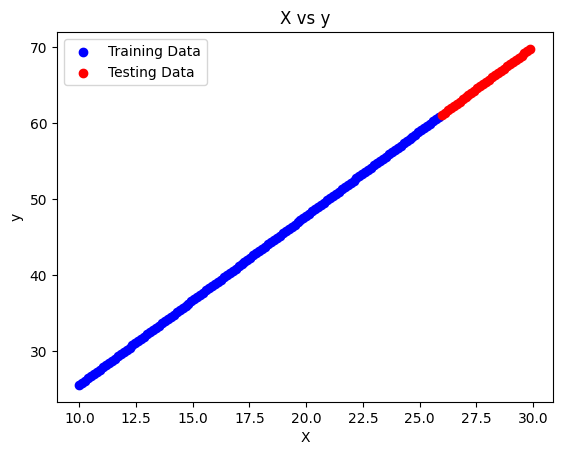

In [198]:
plot_data()

In [199]:
w = np.random.randn()
b = np.random.randn()
print(w)
print(b)

0.857037484634598
-2.1401890821263403


In [200]:
def loss_fn(y_actual, y_out):
    return np.sum(np.square(y_actual - y_out))/ len(y_actual)

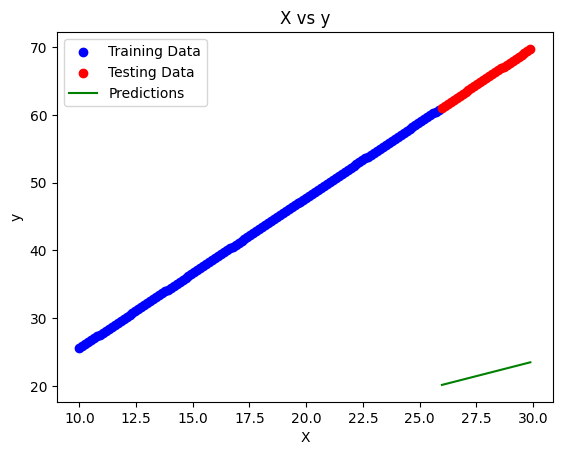

In [201]:
y_out = X_test*w + b
plot_data(predictions=y_out)

In [202]:
lr = 0.001
epochs = 100
train_loss_list, test_loss_list = [], []
for epoch in range(epochs):
    # Forward pass
    train_preds = X_train*w + b
    train_loss = loss_fn(y_train, train_preds)
    # Compute gradients
    gradientW = (-2/len(X_train)) * np.sum((y_train - train_preds)*X_train)
    gradientb = (-2/len(X_train)) * np.sum(y_train - train_preds)
    # Update parameters
    w = w - gradientW*lr
    b = b - gradientb*lr
    # Evaluate on test data
    test_preds = X_test*w + b
    test_loss = loss_fn(y_test, test_preds)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

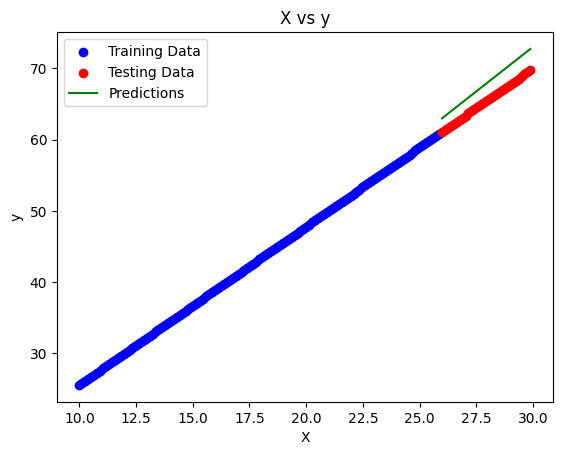

In [203]:
y_out = X_test*w + b
plot_data(predictions=y_out)



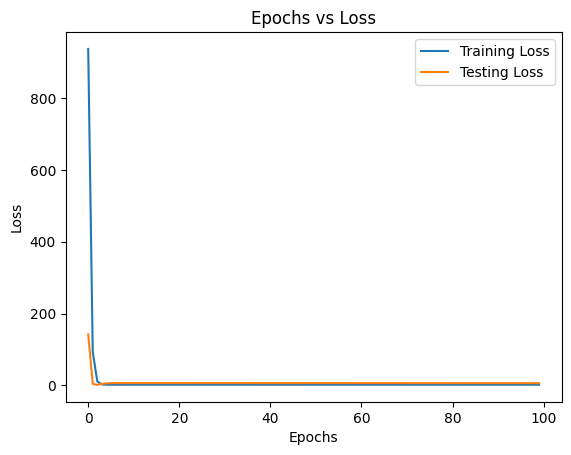

In [204]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss")
plt.xlabel("Epochs");
plt.ylabel("Loss")
plt.legend();
plt.show()

In [205]:
print(f'Finally w={w} and b={b}')

Finally w=2.5003532463579354 and b=-1.9876638355951275
